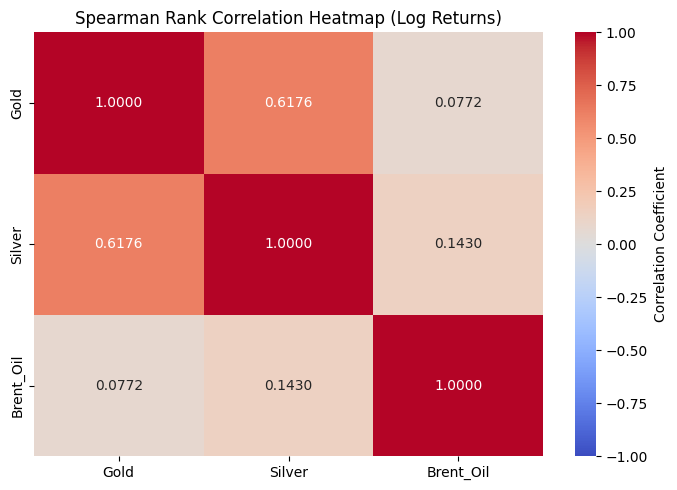

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from matplotlib.backends.backend_pdf import PdfPages

def find_kaggle_file(filename):
    input_dir = '/kaggle/input'
    for root, dirs, files in os.walk(input_dir):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename}")

gold_df = pd.read_csv(find_kaggle_file('Gold 100years.csv'), parse_dates=['Date']).set_index('Date')
silver_df = pd.read_csv(find_kaggle_file('silver 100 years.csv'), parse_dates=['Date']).set_index('Date')
brent_df = pd.read_csv(find_kaggle_file('Brent Oil.csv'), parse_dates=['Date']).set_index('Date')


gold_df = gold_df.rename(columns={'Value': 'Gold'})
silver_df = silver_df.rename(columns={'Value': 'Silver'})
brent_df = brent_df.rename(columns={'Value': 'Brent_Oil'})

commodities = gold_df.join([silver_df, brent_df], how='inner')

log_returns = np.log(commodities / commodities.shift(1)).dropna()
spearman_corr, _ = spearmanr(log_returns)
spearman_df = pd.DataFrame(spearman_corr, index=commodities.columns, columns=commodities.columns)


with PdfPages('task1_spearman_heatmap.pdf') as pdf:
    plt.figure(figsize=(7, 5))
    sns.heatmap(spearman_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Spearman Rank Correlation Heatmap (Log Returns)')
    plt.tight_layout()
    pdf.savefig()  
    plt.show()
    plt.close()